In [ ]:
#This final code is to study the relationship between economic changes (total, percentage..) and election results and margins.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc('figure', figsize=(8, 6))

#Necessary files
pctdelta = pd.read_csv("pctdelta.csv", index_col=0)
totdelta = pd.read_csv("totdelta.csv", index_col=0)
df2319 = pd.read_csv("difference23_19.csv", index_col=0)
perc24 = pd.read_csv("election_percentages_24.csv", index_col=0, header=None, names=["GeoName", "REPUBLICAN", "DEMOCRAT"], skiprows=1)
perc7620 = pd.read_csv("election_percentages_76_20.csv", index_col=0, skiprows=3, names=["GeoName","DEMOCRAT","REPUBLICAN"])
df23 = pd.read_csv("df_new23.csv", index_col=0)


In [ ]:
perc24.index = perc24.index.str.upper()
#Selecting only elections in year 2020
perc20 = perc7620.loc[2020].reset_index(drop=True)
perc20.set_index("GeoName", inplace=True)
perc20.index= perc20.index.str.upper()
perc20 = perc20.iloc[:,[1,0]].apply(lambda x: round(x*100, 2))

In [ ]:
#2024-2020 election difference
eldelta = perc24-perc20

In [ ]:
#Swing Margin
eldelta["SwingMargin"] = (perc24["REPUBLICAN"]-perc20["REPUBLICAN"]) +
                          abs(perc24["DEMOCRAT"]-perc20["DEMOCRAT"])

In [ ]:
#Margin in 2020 and 2024 elections
perc20["Margin"] = perc20["REPUBLICAN"]-perc20["DEMOCRAT"]
perc24["Margin"] = perc24["REPUBLICAN"]-perc24["DEMOCRAT"]

In [ ]:
#To focus on swing states only
swing24= perc24[abs(perc24["Margin"])<5]
sw_totd = totdelta.loc[totdelta.index.isin(swing24.index)]
sw_pctd = pctdelta.loc[pctdelta.index.isin(swing24.index)]
sw_eld = eldelta.loc[eldelta.index.isin(swing24.index)]

In [ ]:
#Exlude whole USA data and DC data because it's a special case.
excluded=["UNITED STATES","DISTRICT OF COLUMBIA"]

'Totals Delta'

,GDP,PCE,PersonalIncome,JobsNumber,population,Jobs/Population,CGDP,CDPI,CPI,CPCE
GeoName,,,,,,,,,,
ALABAMA,69610.3,51641.1,46193.4,268600,84579,0.043715,12829,7116,8355,9585
ALASKA,16772.6,11067.3,7180.4,36420,3493,0.046662,22441,8611,9753,15061


'Percentages Delta'

,RPP,%Pop_Ch,%PI_Ch,%GDP_Ch,%Jobs_Ch,%PCE_Ch,%CDPI_Ch,%CPI_Ch,%CGDP_Ch,%CPCE_Ch
GeoName,,,,,,,,,,
ALABAMA,2.409,0.016805,0.200204,0.295805,0.100571,0.293693,0.170121,0.182209,0.274388,0.274296
ALASKA,0.365,0.004765,0.158369,0.327057,0.084527,0.315631,0.150195,0.157668,0.320760,0.314827


'Election Delta'

...

,REPUBLICAN,DEMOCRAT,Margin
GeoName,,,
ALABAMA,64.6,34.1,30.5
ALASKA,54.5,41.4,13.1


'2023 Data'

,GDP,CDPI,CPI,PCE,PersonalIncome,RPP,JobsNumber,year,population,Jobs/Population,CGDP,CPCE
GeoName,,,,,,,,,,,,
ALABAMA,304935.6,48945,54209,227475.0,276925.6,89.970,2939353,2023,5117673,0.574353,59584,44529
ALASKA,68056.0,65943,71611,46131.3,52520.0,101.715,467287,2023,736510,0.634461,92403,62900


'Changes 2023-2019'

,Jobs/Population,JobsNumber,population,%Jobs_Ch,%Pop_Ch
ALABAMA,0.021241,227339,214488,0.083827,0.043745
ALASKA,0.012771,12493,4965,0.027470,0.006787


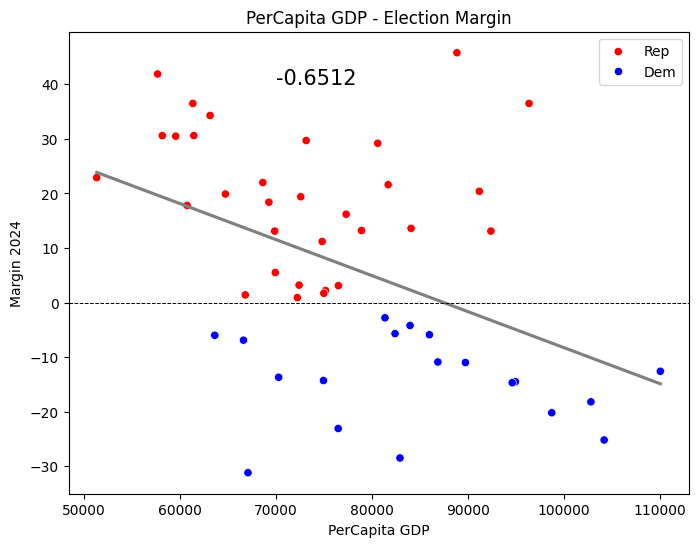

-0.6512010761752893

In [ ]:
corr1 = df23["CGDP"].corr(perc24["Margin"])

pic1 =sns.scatterplot(x=df23["CGDP"].drop(excluded).sort_index(),
                y=perc24["Margin"].drop(excluded).sort_index(),
                hue=perc24["Margin"]>0,
                palette=("blue", "red"))

sns.regplot(x=df23["CGDP"].drop(excluded).sort_index(),
            y=perc24["Margin"].drop(excluded).sort_index(),
            scatter=False, ci=None, color="gray")

pic1.set(xlabel="PerCapita GDP", ylabel="Margin 2024")
pic1.text(x=70000, y=40, s=str(round(corr1, 4)), size=15)

plt.axhline(y=0,color="k", linestyle="--", linewidth=0.7)
plt.legend(labels=["Rep", "Dem"])
plt.title("PerCapita GDP - Election Margin", loc="center")

#plt.savefig("01CGDP-Margin.jpg", bbox_inches="tight")
plt.show()
display(corr1)

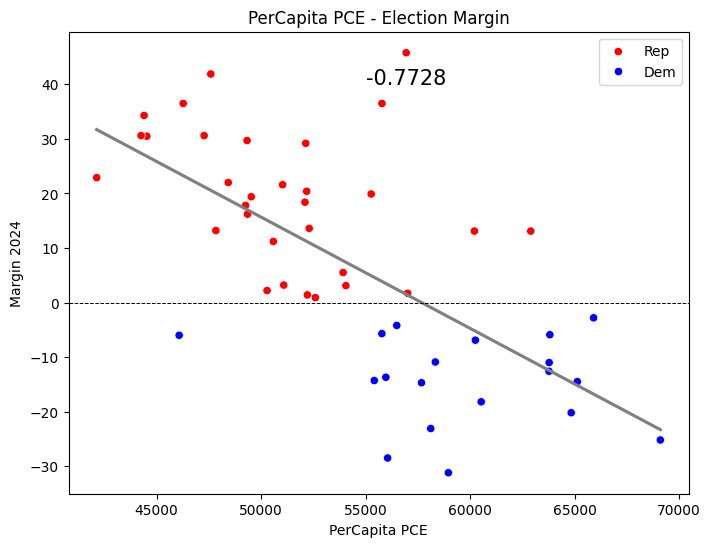

-0.7727740103620767

In [ ]:
corr2 = df23["CPCE"].corr(perc24["Margin"])

pic2 =sns.scatterplot(x=df23["CPCE"].drop(excluded).sort_index(),
                y=perc24["Margin"].drop(excluded).sort_index(),
                hue=perc24["Margin"]>0,
                palette=("blue", "red"))

sns.regplot(x=df23["CPCE"].drop(excluded).sort_index(),
            y=perc24["Margin"].drop(excluded).sort_index(),
            scatter=False, ci=None, color="gray")

pic2.set(xlabel="PerCapita PCE", ylabel="Margin 2024")
pic2.text(x=55000, y=40, s=str(round(corr2, 4)), size=15)

plt.axhline(y=0,color="k", linestyle="--", linewidth=0.7)
plt.legend(labels=["Rep", "Dem"])
plt.title("PerCapita PCE - Election Margin", loc="center")

#plt.savefig("02CPCE-Margin.jpg", bbox_inches="tight")
plt.show()
display(corr2)

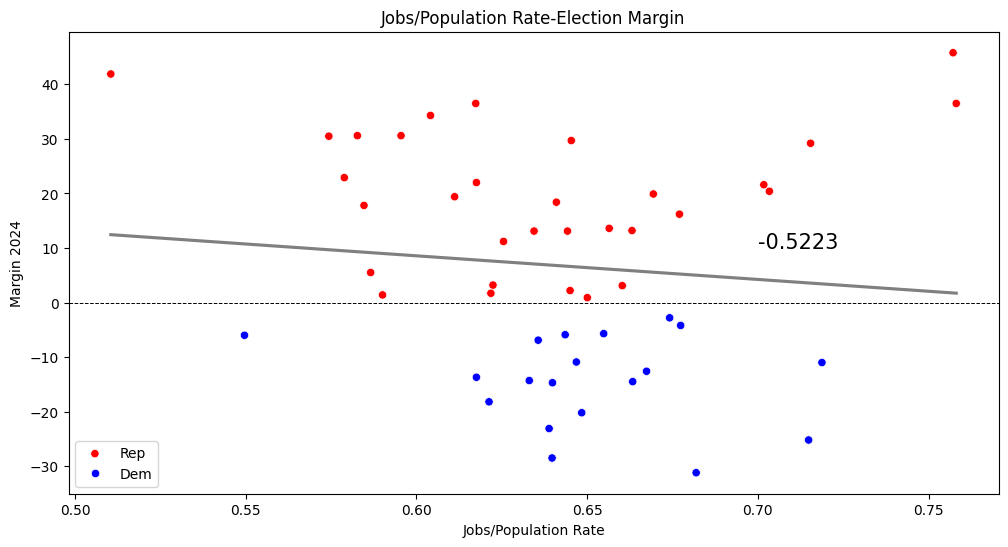

-0.5223034147482164

In [ ]:
plt.rc('figure', figsize=(12, 6))
corr3 = df23["Jobs/Population"].corr(perc24["Margin"])

pic3 =sns.scatterplot(x=df23["Jobs/Population"].drop(excluded).sort_index(),
                y=perc24["Margin"].drop(excluded).sort_index(),
                hue=perc24["Margin"]>0,
                palette=("blue", "red"))

sns.regplot(x=df23["Jobs/Population"].drop(excluded).sort_index(),
            y=perc24["Margin"].drop(excluded).sort_index(),
            scatter=False, ci=None, color="gray")

pic3.set(xlabel="Jobs/Population Rate", ylabel="Margin 2024")
pic3.text(x=0.70, y=10, s=str(round(corr3, 4)), size=15)

plt.axhline(y=0,color="k", linestyle="--", linewidth=0.7)
plt.legend(labels=["Rep", "Dem"])
plt.title("Jobs/Population Rate-Election Margin", loc="center")

#plt.savefig("03JobsPopulation-Margin.jpg", bbox_inches="tight")
plt.show()
display(corr3)
#display(df23["Jobs/Population"].sort_values())

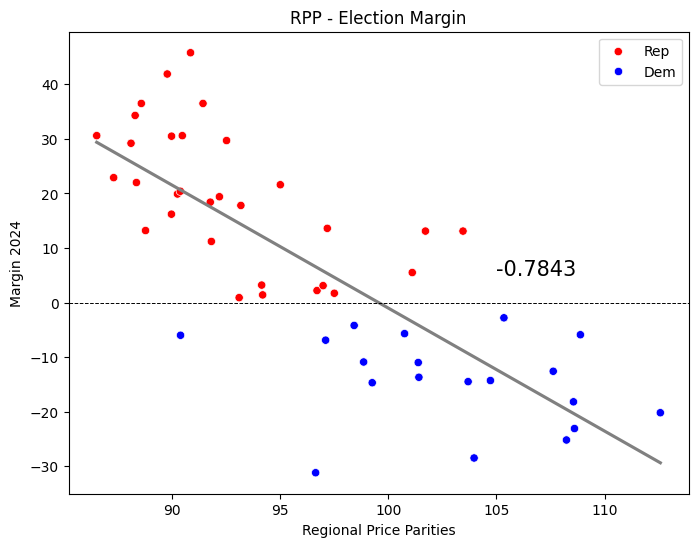

-0.7842824784863777

In [ ]:
plt.rc('figure', figsize=(8, 6))
corr4 = df23["RPP"].corr(perc24["Margin"])

pic4 =sns.scatterplot(x=df23["RPP"].drop(excluded).sort_index(),
                y=perc24["Margin"].drop(excluded).sort_index(),
                hue=perc24["Margin"]>0,
                palette=("blue", "red"))

sns.regplot(x=df23["RPP"].drop(excluded).sort_index(),
            y=perc24["Margin"].drop(excluded).sort_index(),
            scatter=False, ci=None, color="gray")

pic4.set(xlabel="Regional Price Parities", ylabel="Margin 2024")
pic4.text(x=105, y=5, s=str(round(corr4, 4)), size=15)

plt.axhline(y=0,color="k", linestyle="--", linewidth=0.7)
plt.legend(labels=["Rep", "Dem"])
plt.title("RPP - Election Margin", loc="center")

#plt.savefig("04RPP-Margin.jpg", bbox_inches="tight")
plt.show()
display(corr4)

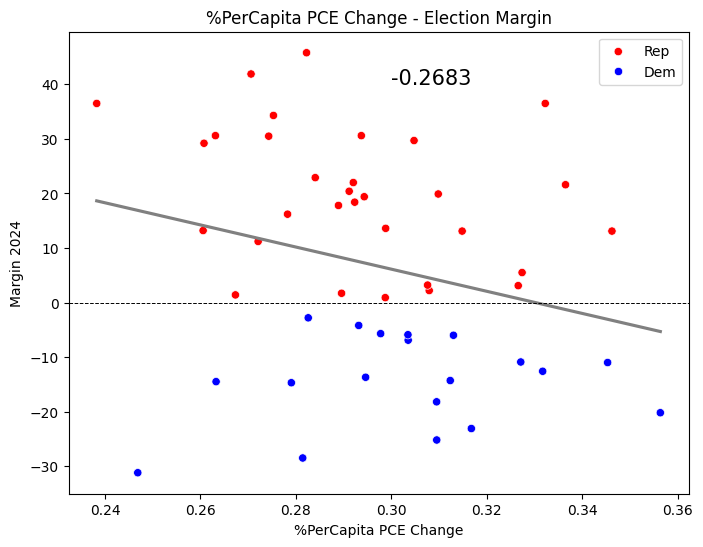

-0.26833263130826357

In [ ]:
corr5 = pctdelta["%CPCE_Ch"].corr(perc24["Margin"])

pic5 =sns.scatterplot(x=pctdelta["%CPCE_Ch"].drop(excluded).sort_index(),
                y=perc24["Margin"].drop(excluded).sort_index(),
                hue=perc24["Margin"]>0,
                palette=("blue", "red"))

sns.regplot(x=pctdelta["%CPCE_Ch"].drop(excluded).sort_index(),
            y=perc24["Margin"].drop(excluded).sort_index(),
            scatter=False, ci=None, color="gray")

pic5.set(xlabel="%PerCapita PCE Change", ylabel="Margin 2024")
pic5.text(x=0.3, y=40, s=str(round(corr5, 4)), size=15)

plt.axhline(y=0,color="k", linestyle="--", linewidth=0.7)
plt.legend(labels=["Rep", "Dem"])
plt.title("%PerCapita PCE Change - Election Margin", loc="center")

#plt.savefig("05%CPCE_Ch-Margin.jpg", bbox_inches="tight")
plt.show()
display(corr5)

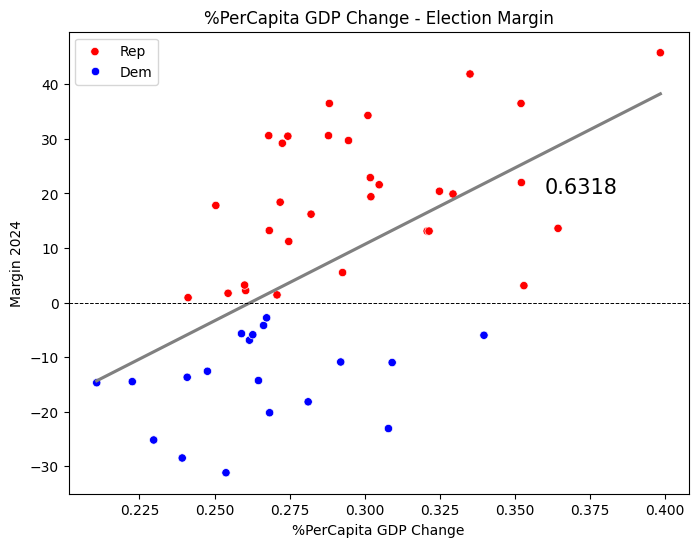

0.6318310232877812

In [ ]:
corr6 = pctdelta["%CGDP_Ch"].corr(perc24["Margin"])

pic6 =sns.scatterplot(x=pctdelta["%CGDP_Ch"].drop(excluded).sort_index(),
                y=perc24["Margin"].drop(excluded).sort_index(),
                hue=perc24["Margin"]>0,
                palette=("blue", "red"))

sns.regplot(x=pctdelta["%CGDP_Ch"].drop(excluded).sort_index(),
            y=perc24["Margin"].drop(excluded).sort_index(),
            scatter=False, ci=None, color="gray")

pic6.set(xlabel="%PerCapita GDP Change", ylabel="Margin 2024")
pic6.text(x=0.36, y=20, s=str(round(corr6, 4)), size=15)

plt.axhline(y=0,color="k", linestyle="--", linewidth=0.7)
plt.legend(labels=["Rep", "Dem"])
plt.title("%PerCapita GDP Change - Election Margin", loc="center")

#plt.savefig("06%CGDP_Ch-Margin.jpg", bbox_inches="tight")
plt.show()
display(corr6)
#display(pctdelta["%CGDP_Ch"].sort_values())

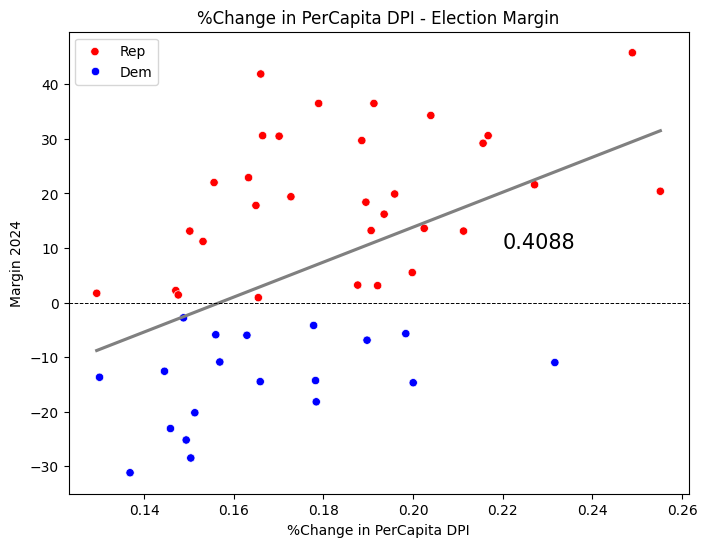

0.4088228037791277

In [ ]:
corr7 = pctdelta["%CDPI_Ch"].corr(perc24["Margin"])

pic7 =sns.scatterplot(x=pctdelta["%CDPI_Ch"].drop(excluded).sort_index(),
                y=perc24["Margin"].drop(excluded).sort_index(),
                hue=perc24["Margin"]>0,
                palette=("blue", "red"))

sns.regplot(x=pctdelta["%CDPI_Ch"].drop(excluded).sort_index(),
            y=perc24["Margin"].drop(excluded).sort_index(),
            scatter=False, ci=None, color="gray")

pic7.set(xlabel="%Change in PerCapita DPI", ylabel="Margin 2024")
pic7.text(x=0.22, y=10, s=str(round(corr7, 4)), size=15)

plt.axhline(y=0,color="k", linestyle="--", linewidth=0.7)
plt.legend(labels=["Rep", "Dem"])
plt.title("%Change in PerCapita DPI - Election Margin", loc="center")

#plt.savefig("07%CDPI_Ch-Margin.jpg", bbox_inches="tight")
plt.show()
display(corr7)
#display(pctdelta["%CDPI_Ch"].sort_values())

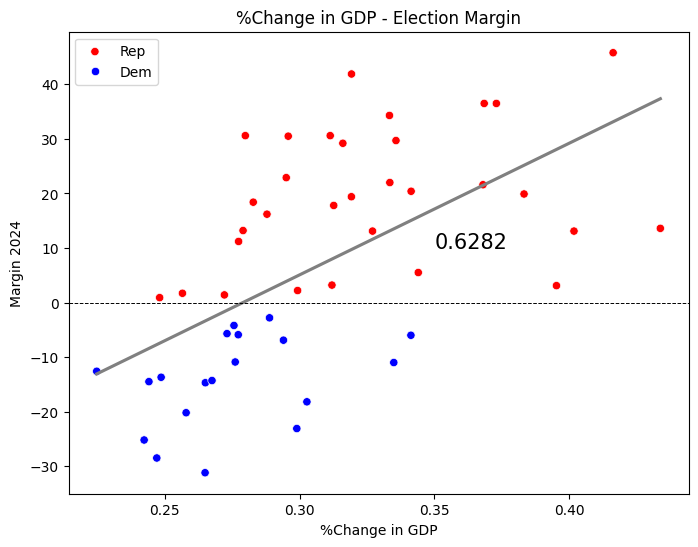

0.6281625329718852

In [ ]:
corr8 = pctdelta["%GDP_Ch"].corr(perc24["Margin"])

pic8 =sns.scatterplot(x=pctdelta["%GDP_Ch"].drop(excluded).sort_index(),
                y=perc24["Margin"].drop(excluded).sort_index(),
                hue=perc24["Margin"]>0,
                palette=("blue", "red"))

sns.regplot(x=pctdelta["%GDP_Ch"].drop(excluded).sort_index(),
            y=perc24["Margin"].drop(excluded).sort_index(),
            scatter=False, ci=None, color="gray")

pic8.set(xlabel="%Change in GDP", ylabel="Margin 2024")
pic8.text(x=0.35, y=10, s=str(round(corr8, 4)), size=15)

plt.axhline(y=0,color="k", linestyle="--", linewidth=0.7)
plt.legend(labels=["Rep", "Dem"])
plt.title("%Change in GDP - Election Margin", loc="center")

#plt.savefig("08%GDP_Ch-Margin.jpg", bbox_inches="tight")
plt.show()
display(corr8)

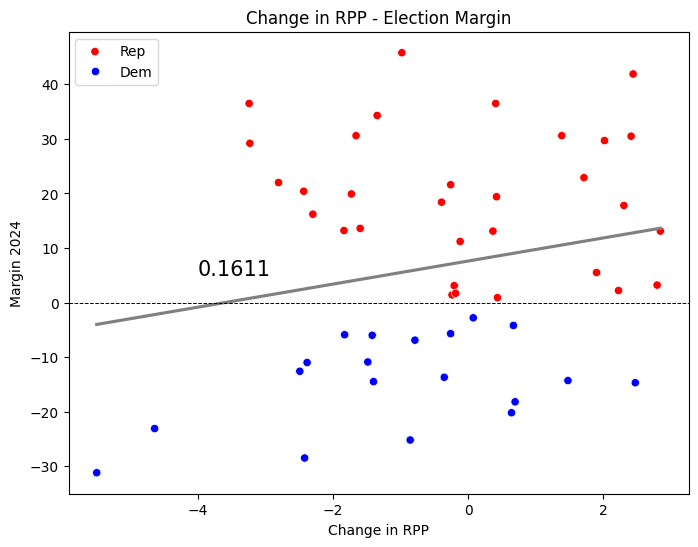

0.16108749291647248

In [ ]:
corr9 = pctdelta["RPP"].corr(perc24["Margin"])

pic9 =sns.scatterplot(x=pctdelta["RPP"].drop(excluded).sort_index(),
                y=perc24["Margin"].drop(excluded).sort_index(),
                hue=perc24["Margin"]>0,
                palette=("blue", "red"))

sns.regplot(x=pctdelta["RPP"].drop(excluded).sort_index(),
            y=perc24["Margin"].drop(excluded).sort_index(),
            scatter=False, ci=None, color="gray")

pic9.set(xlabel="Change in RPP", ylabel="Margin 2024")
pic9.text(x=-4, y=5, s=str(round(corr9, 4)), size=15)

plt.axhline(y=0,color="k", linestyle="--", linewidth=0.7)
plt.legend(labels=["Rep", "Dem"])
plt.title("Change in RPP - Election Margin", loc="center")

#plt.savefig("09%RPP_Ch-Margin.jpg", bbox_inches="tight")
plt.show()
display(corr9)

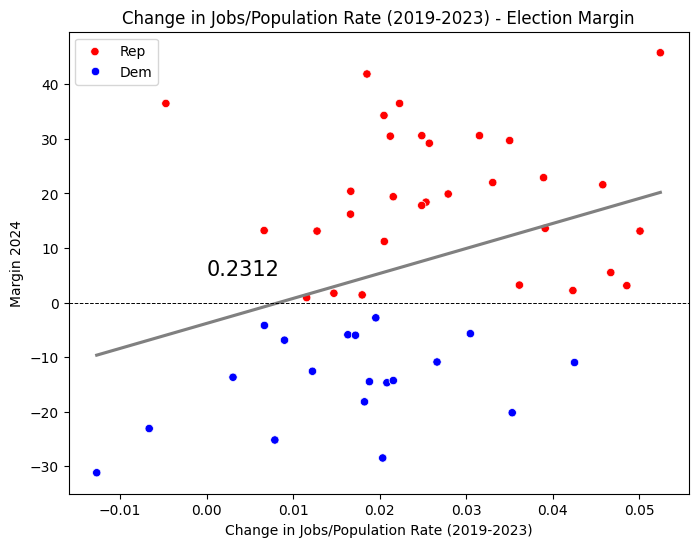

0.23117985952967046

In [ ]:
corr10 = df2319["Jobs/Population"].corr(perc24["Margin"])

pic10 =sns.scatterplot(x=df2319["Jobs/Population"].drop(excluded).sort_index(),
                y=perc24["Margin"].drop(excluded).sort_index(),
                hue=perc24["Margin"]>0,
                palette=("blue", "red"))

sns.regplot(x=df2319["Jobs/Population"].drop(excluded).sort_index(),
            y=perc24["Margin"].drop(excluded).sort_index(),
            scatter=False, ci=None, color="gray")

pic10.set(xlabel="Change in Jobs/Population Rate (2019-2023)", ylabel="Margin 2024")
pic10.text(x=0, y=5, s=str(round(corr10, 4)), size=15)

plt.axhline(y=0,color="k", linestyle="--", linewidth=0.7)
plt.legend(labels=["Rep", "Dem"])
plt.title("Change in Jobs/Population Rate (2019-2023) - Election Margin", loc="center")

#plt.savefig("10%JobsPopulation_Ch-Margin.jpg", bbox_inches="tight")
plt.show()
display(corr10)

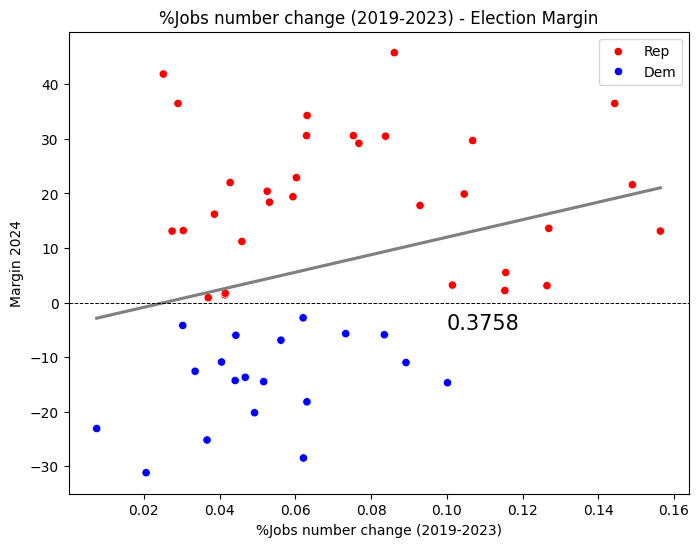

0.3757635030391276

In [ ]:
corr11 = df2319["%Jobs_Ch"].corr(perc24["Margin"])

pic11 =sns.scatterplot(x=df2319["%Jobs_Ch"].drop(excluded).sort_index(),
                y=perc24["Margin"].drop(excluded).sort_index(),
                hue=perc24["Margin"]>0,
                palette=("blue", "red"))

sns.regplot(x=df2319["%Jobs_Ch"].drop(excluded).sort_index(),
            y=perc24["Margin"].drop(excluded).sort_index(),
            scatter=False, ci=None, color="gray")

pic11.set(xlabel="%Jobs number change (2019-2023)", ylabel="Margin 2024")
pic11.text(x=0.1, y=-5, s=str(round(corr11, 4)), size=15)

plt.axhline(y=0,color="k", linestyle="--", linewidth=0.7)
plt.legend(labels=["Rep", "Dem"])
plt.title("%Jobs number change (2019-2023) - Election Margin", loc="center")

#plt.savefig("11%Jobs_Ch-Margin.jpg", bbox_inches="tight")
plt.show()
display(corr11)

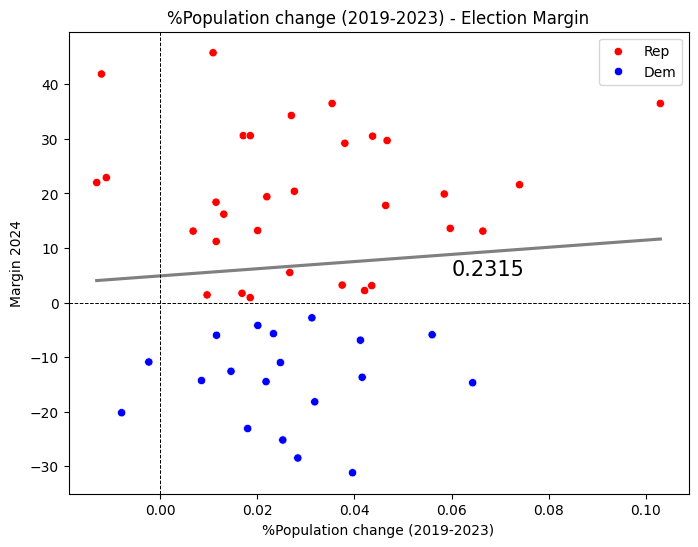

0.23151374327457896

,%Pop_Ch
GeoName,
NEW YORK,-0.018294
LOUISIANA,-0.013806
ILLINOIS,-0.012253
WEST VIRGINIA,-0.011805
CALIFORNIA,-0.008179
HAWAII,-0.006798
MISSISSIPPI,-0.005193
MICHIGAN,0.001058
NEW MEXICO,0.001207


In [ ]:
corr12 = df2319["%Pop_Ch"].corr(perc24["Margin"])

pic12 =sns.scatterplot(x=df2319["%Pop_Ch"].drop(excluded).sort_index(),
                y=perc24["Margin"].drop(excluded).sort_index(),
                hue=perc24["Margin"]>0,
                palette=("blue", "red"))

sns.regplot(x=df2319["%Pop_Ch"].drop(excluded).sort_index(),
            y=perc24["Margin"].drop(excluded).sort_index(),
            scatter=False, ci=None, color="gray")

pic12.set(xlabel="%Population change (2019-2023)", ylabel="Margin 2024")
pic12.text(x=0.06, y=5, s=str(round(corr12, 4)), size=15)

plt.axhline(y=0,color="k", linestyle="--", linewidth=0.7)
plt.axvline(x=0,color="k", linestyle="--", linewidth=0.7)

plt.legend(labels=["Rep", "Dem"])
plt.title("%Population change (2019-2023) - Election Margin", loc="center")

#plt.savefig("12%Pop_Ch-Margin.jpg", bbox_inches="tight")
plt.show()
display(corr12)
#display(pctdelta["%Pop_Ch"].sort_values())

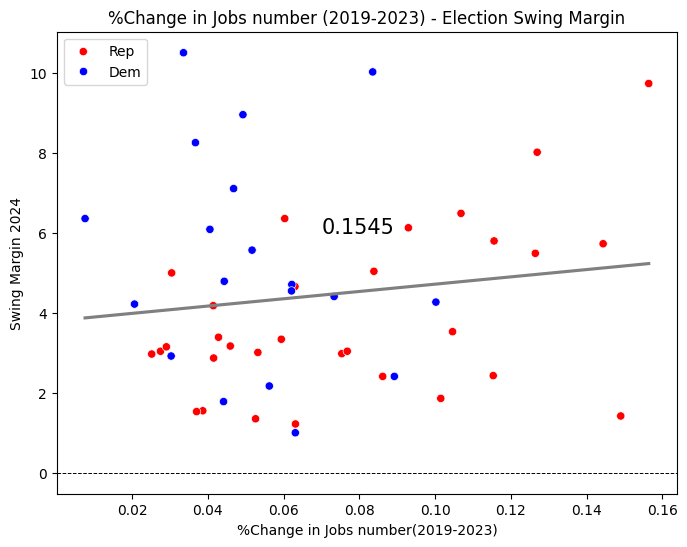

0.15445020544011456

In [ ]:
corr13 = df2319["%Jobs_Ch"].corr(eldelta["SwingMargin"])

pic13 =sns.scatterplot(x=df2319["%Jobs_Ch"].drop(excluded).sort_index(),
                y=eldelta["SwingMargin"].drop(excluded).sort_index(),
                hue=perc24["Margin"]>0,
                palette=("blue", "red"))

sns.regplot(x=df2319["%Jobs_Ch"].drop(excluded).sort_index(),
            y=eldelta["SwingMargin"].drop(excluded).sort_index(),
            scatter=False, ci=None, color="gray")

pic13.set(xlabel="%Change in Jobs number(2019-2023)", ylabel="Swing Margin 2024")
pic13.text(x=0.07, y=6, s=str(round(corr13, 4)), size=15)

plt.axhline(y=0,color="k", linestyle="--", linewidth=0.7)

plt.legend(labels=["Rep", "Dem"])
plt.title("%Change in Jobs number (2019-2023) - Election Swing Margin", loc="center")

#plt.savefig("13%Jobs_Ch-SwingMargin.jpg", bbox_inches="tight")
plt.show()
display(corr13)

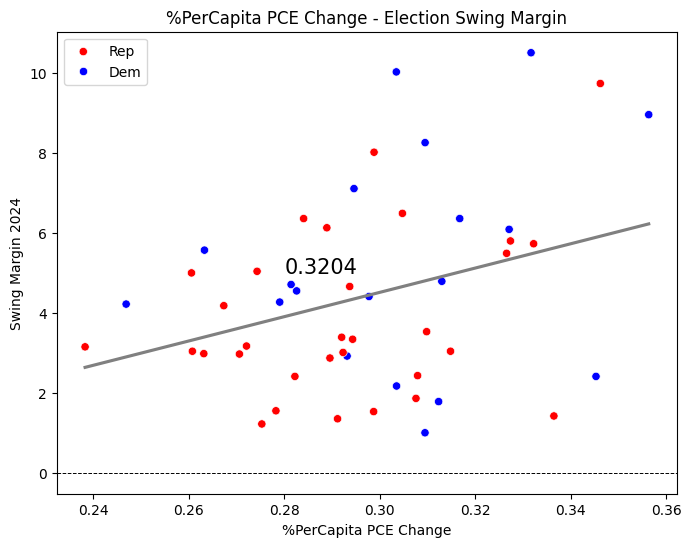

0.3203864399627893

In [ ]:
corr14 = pctdelta["%CPCE_Ch"].corr(eldelta["SwingMargin"])

pic14 =sns.scatterplot(x=pctdelta["%CPCE_Ch"].drop(excluded).sort_index(),
                y=eldelta["SwingMargin"].drop(excluded).sort_index(),
                hue=perc24["Margin"]>0,
                palette=("blue", "red"))

sns.regplot(x=pctdelta["%CPCE_Ch"].drop(excluded).sort_index(),
            y=eldelta["SwingMargin"].drop(excluded).sort_index(),
            scatter=False, ci=None, color="gray")

pic14.set(xlabel="%PerCapita PCE Change", ylabel="Swing Margin 2024")
pic14.text(x=0.28, y=5, s=str(round(corr14, 4)), size=15)

plt.axhline(y=0,color="k", linestyle="--", linewidth=0.7)

plt.legend(labels=["Rep", "Dem"])
plt.title("%PerCapita PCE Change - Election Swing Margin", loc="center")

#plt.savefig("14%CPCE_Ch-SwingMargin.jpg", bbox_inches="tight")
plt.show()
display(corr14)
#display(pctdelta["%CPCE_Ch"].sort_values())

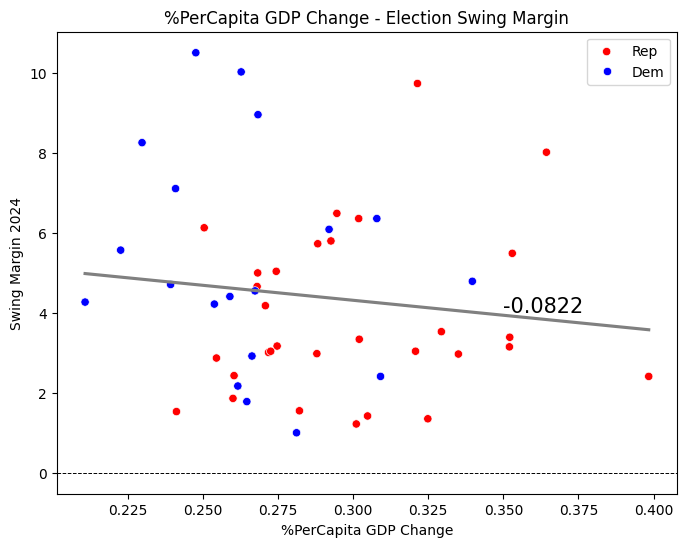

-0.08215825249007294

In [ ]:
corr15 = pctdelta["%CGDP_Ch"].corr(eldelta["SwingMargin"])

pic15 =sns.scatterplot(x=pctdelta["%CGDP_Ch"].drop(excluded).sort_index(),
                y=eldelta["SwingMargin"].drop(excluded).sort_index(),
                hue=perc24["Margin"]>0,
                palette=("blue", "red"))

sns.regplot(x=pctdelta["%CGDP_Ch"].drop(excluded).sort_index(),
            y=eldelta["SwingMargin"].drop(excluded).sort_index(),
            scatter=False, ci=None, color="gray")

pic15.set(xlabel="%PerCapita GDP Change", ylabel="Swing Margin 2024")
pic15.text(x=0.35, y=4, s=str(round(corr15, 4)), size=15)

plt.axhline(y=0,color="k", linestyle="--", linewidth=0.7)

plt.legend(labels=["Rep", "Dem"])
plt.title("%PerCapita GDP Change - Election Swing Margin", loc="center")

#plt.savefig("15%CGDP_Ch-SwingMargin.jpg", bbox_inches="tight")
plt.show()
display(corr15)

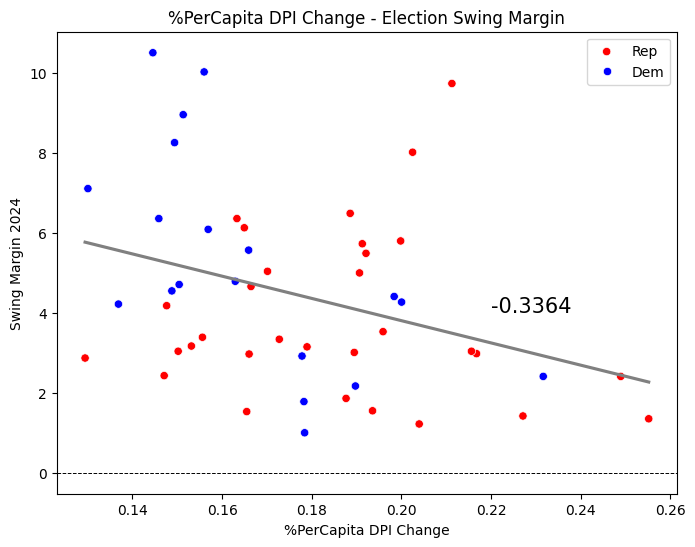

-0.3364440620472753

In [ ]:
corr16 = pctdelta["%CDPI_Ch"].corr(eldelta["SwingMargin"])

pic16 =sns.scatterplot(x=pctdelta["%CDPI_Ch"].drop(excluded).sort_index(),
                y=eldelta["SwingMargin"].drop(excluded).sort_index(),
                hue=perc24["Margin"]>0,
                palette=("blue", "red"))

sns.regplot(x=pctdelta["%CDPI_Ch"].drop(excluded).sort_index(),
            y=eldelta["SwingMargin"].drop(excluded).sort_index(),
            scatter=False, ci=None, color="gray")

pic16.set(xlabel="%PerCapita DPI Change", ylabel="Swing Margin 2024")
pic16.text(x=0.22, y=4, s=str(round(corr16, 4)), size=15)

plt.axhline(y=0,color="k", linestyle="--", linewidth=0.7)

plt.legend(labels=["Rep", "Dem"])
plt.title("%PerCapita DPI Change - Election Swing Margin", loc="center")

#plt.savefig("16%CDPI_Ch-SwingMargin.jpg", bbox_inches="tight")
plt.show()
display(corr16)

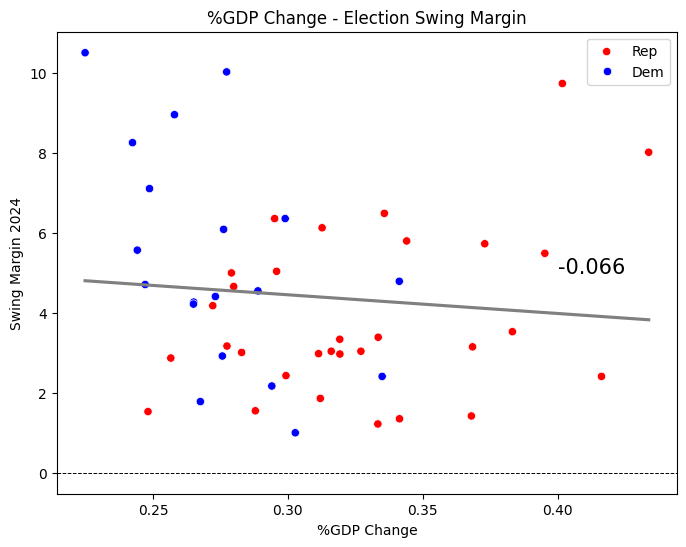

-0.06600829272427214

In [ ]:
corr17 = pctdelta["%GDP_Ch"].corr(eldelta["SwingMargin"])

pic17 =sns.scatterplot(x=pctdelta["%GDP_Ch"].drop(excluded).sort_index(),
                y=eldelta["SwingMargin"].drop(excluded).sort_index(),
                hue=perc24["Margin"]>0,
                palette=("blue", "red"))

sns.regplot(x=pctdelta["%GDP_Ch"].drop(excluded).sort_index(),
            y=eldelta["SwingMargin"].drop(excluded).sort_index(),
            scatter=False, ci=None, color="gray")

pic17.set(xlabel="%GDP Change", ylabel="Swing Margin 2024")
pic17.text(x=0.4, y=5, s=str(round(corr17, 4)), size=15)

plt.axhline(y=0,color="k", linestyle="--", linewidth=0.7)

plt.legend(labels=["Rep", "Dem"])
plt.title("%GDP Change - Election Swing Margin", loc="center")

#plt.savefig("17%GDP_Ch-SwingMargin.jpg", bbox_inches="tight")
plt.show()
display(corr17)

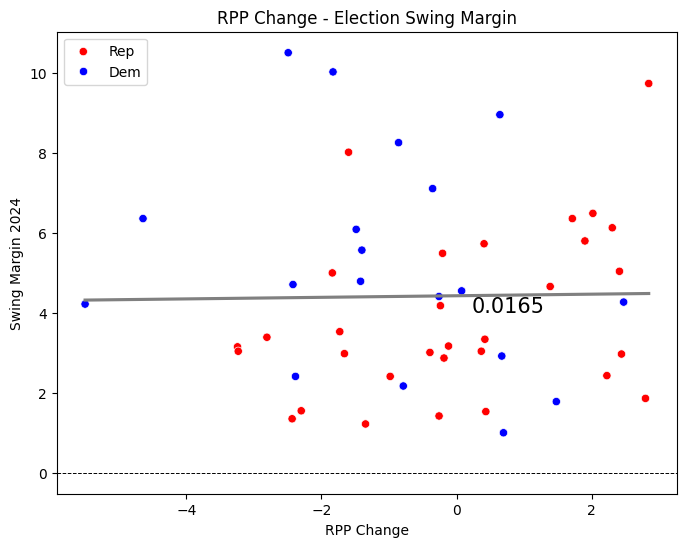

0.01648699441764642

In [ ]:
corr18 = pctdelta["RPP"].corr(eldelta["SwingMargin"])

pic18 =sns.scatterplot(x=pctdelta["RPP"].drop(excluded).sort_index(),
                y=eldelta["SwingMargin"].drop(excluded).sort_index(),
                hue=perc24["Margin"]>0,
                palette=("blue", "red"))

sns.regplot(x=pctdelta["RPP"].drop(excluded).sort_index(),
            y=eldelta["SwingMargin"].drop(excluded).sort_index(),
            scatter=False, ci=None, color="gray")

pic18.set(xlabel="RPP Change", ylabel="Swing Margin 2024")
pic18.text(x=0.22, y=4, s=str(round(corr18, 4)), size=15)

plt.axhline(y=0,color="k", linestyle="--", linewidth=0.7)

plt.legend(labels=["Rep", "Dem"])
plt.title("RPP Change - Election Swing Margin", loc="center")

#plt.savefig("18%RPP_Ch-SwingMargin.jpg", bbox_inches="tight")
plt.show()
display(corr18)

In [ ]:
# display(sw_eldelta)
# display(sw_totdelta)
# display(sw_pctdelta)
# display("Totals Delta",totdelta.sort_index().head(2))
display("Percentages Delta",pctdelta.sort_index().head(2))
display("Election Delta",eldelta.sort_index().head(2))
display("2024 Elections Results",perc24.sort_index().head(2))
display("2023 Data",df23.sort_index().head(2))
display("Changes 2023-2019",df2319.sort_index().head(2))

'Percentages Delta'

,RPP,%Pop_Ch,%PI_Ch,%GDP_Ch,%Jobs_Ch,%PCE_Ch,%CDPI_Ch,%CPI_Ch,%CGDP_Ch,%CPCE_Ch
GeoName,,,,,,,,,,
ALABAMA,2.409,0.016805,0.200204,0.295805,0.100571,0.293693,0.170121,0.182209,0.274388,0.274296
ALASKA,0.365,0.004765,0.158369,0.327057,0.084527,0.315631,0.150195,0.157668,0.320760,0.314827


'Election Delta'

,REPUBLICAN,DEMOCRAT,SwingMargin
GeoName,,,
ALABAMA,2.57,-2.47,5.04
ALASKA,1.67,-1.37,3.04


'2024 Elections Results'

,REPUBLICAN,DEMOCRAT,Margin
GeoName,,,
ALABAMA,64.6,34.1,30.5
ALASKA,54.5,41.4,13.1


'2023 Data'

,GDP,CDPI,CPI,PCE,PersonalIncome,RPP,JobsNumber,year,population,Jobs/Population,CGDP,CPCE
GeoName,,,,,,,,,,,,
ALABAMA,304935.6,48945,54209,227475.0,276925.6,89.970,2939353,2023,5117673,0.574353,59584,44529
ALASKA,68056.0,65943,71611,46131.3,52520.0,101.715,467287,2023,736510,0.634461,92403,62900


'Changes 2023-2019'

,Jobs/Population,JobsNumber,population,%Jobs_Ch,%Pop_Ch
ALABAMA,0.021241,227339,214488,0.083827,0.043745
ALASKA,0.012771,12493,4965,0.027470,0.006787
